# Programming in Python II - Final Coding Project

Author: KOREN Luca Kasian

Student ID: Luca Kasian Koren

Save this file under a file name in the format k+matriculation_number.ipynb, e.g. *k1234567.ipynb*. Remember that for final submission all code cells must run without errors and all cells have to be evaluated.

The code cells are a basic scaffold - you can of course add new code cells if necessary. However, stick to the overall structure of the template to facilitate grading. Ensure to comment your code and structure it reasonably.

In [1]:
# This is just a minimum setup for reproducibility. Add more libraries as required.

import numpy as np
import torch
import matplotlib.pyplot as plt
import os

# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [2]:
# checking successful setup
print(f"Using device: {device}")

Using device: cpu


In [3]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [4]:
# Set working directory to the project folder
os.chdir("my_project_folder")  # Change this to your project folder path
print(f"Current working directory: {os.getcwd()}")

Current working directory: C:\Users\lucak\Desktop\Anaconda\Python2\my_project_folder\my_project_folder


In [5]:
# creating folder 'assets' if necessary
os.makedirs("assets", exist_ok=True)

## Data Handling and Pre-Processing

In [6]:
# Import required libraries
import pandas as pd
from pathlib import Path

# Define project directories
DATA_DIR = "data"
TEST_DIR = "public_test_data"

PLOTS_DIR = "assets/plots"
WEIGHTS_DIR = "assets/weights"

def preprocess(data_folder):
    """
    Creates a dataframe containing image paths and labels.
    Returns:
        dataset (DataFrame): Image metadata
        label_dict (dict): Maps label IDs to class names
    """

    # Convert string path to Path object
    data_folder = Path(data_folder)

    # Get all class folder names and sort them alphabetically
    class_names = sorted(
        [folder.name for folder in data_folder.iterdir() if folder.is_dir()]
    )

    # Create mappings between class names and numeric labels
    label_dict = {idx: cls for idx, cls in enumerate(class_names)}
    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

    rows = []

    # Iterate through each class folder
    for cls in class_names:

        folder = data_folder / cls

        # Collect all jpg images from the current class
        for img_path in folder.glob("*.jpg"):

            rows.append(
                {
                    "folder": str(folder),      # Image directory
                    "file_name": img_path.name, # Image filename
                    "label": class_to_idx[cls]  # Numeric class label
                }
            )

    # Convert collected metadata into a dataframe
    dataset = pd.DataFrame(rows)

    return dataset, label_dict

# Load dataset metadata and label mappings
dataset, label_dict = preprocess(DATA_DIR)

# Display first samples
dataset.head()

,folder,file_name,label
0,data\AnnualCrop,AnnualCrop_1.jpg,0
1,data\AnnualCrop,AnnualCrop_100.jpg,0
2,data\AnnualCrop,AnnualCrop_1004.jpg,0
3,data\AnnualCrop,AnnualCrop_1005.jpg,0
4,data\AnnualCrop,AnnualCrop_101.jpg,0


In [7]:
# checking successful dataframe loading

# uncomment after preprocessing the dataset and adapt the variable name
# print(f"Length of dataset: {len(dataset)}") # Should be 10000
print(dataset.head())
print()
print(label_dict)

print(f"Length of dataset: {len(dataset)}")

            folder            file_name  label
0  data\AnnualCrop     AnnualCrop_1.jpg      0
1  data\AnnualCrop   AnnualCrop_100.jpg      0
2  data\AnnualCrop  AnnualCrop_1004.jpg      0
3  data\AnnualCrop  AnnualCrop_1005.jpg      0
4  data\AnnualCrop   AnnualCrop_101.jpg      0

{0: 'AnnualCrop', 1: 'Forest', 2: 'HerbaceousVegetation', 3: 'Highway', 4: 'Industrial', 5: 'Pasture', 6: 'PermanentCrop', 7: 'Residential', 8: 'River', 9: 'SeaLake'}
Length of dataset: 10000


In [8]:
# Split dataset into training and validation sets
from sklearn.model_selection import train_test_split

SEED = 42

# Use an 80/20 split while preserving class distribution
train_df, val_df = train_test_split(
    dataset,
    test_size=0.2,
    stratify=dataset["label"],
    shuffle=True,
    random_state=SEED
)

# Reset dataframe indices after splitting
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Display number of samples in each subset
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

# Show class distribution in the training set
print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

# Show class distribution in the validation set
print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

Training samples: 8000
Validation samples: 2000

Training distribution:
label
0    800
1    800
2    800
3    800
4    800
5    800
6    800
7    800
8    800
9    800
Name: count, dtype: int64

Validation distribution:
label
0    200
1    200
2    200
3    200
4    200
5    200
6    200
7    200
8    200
9    200
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

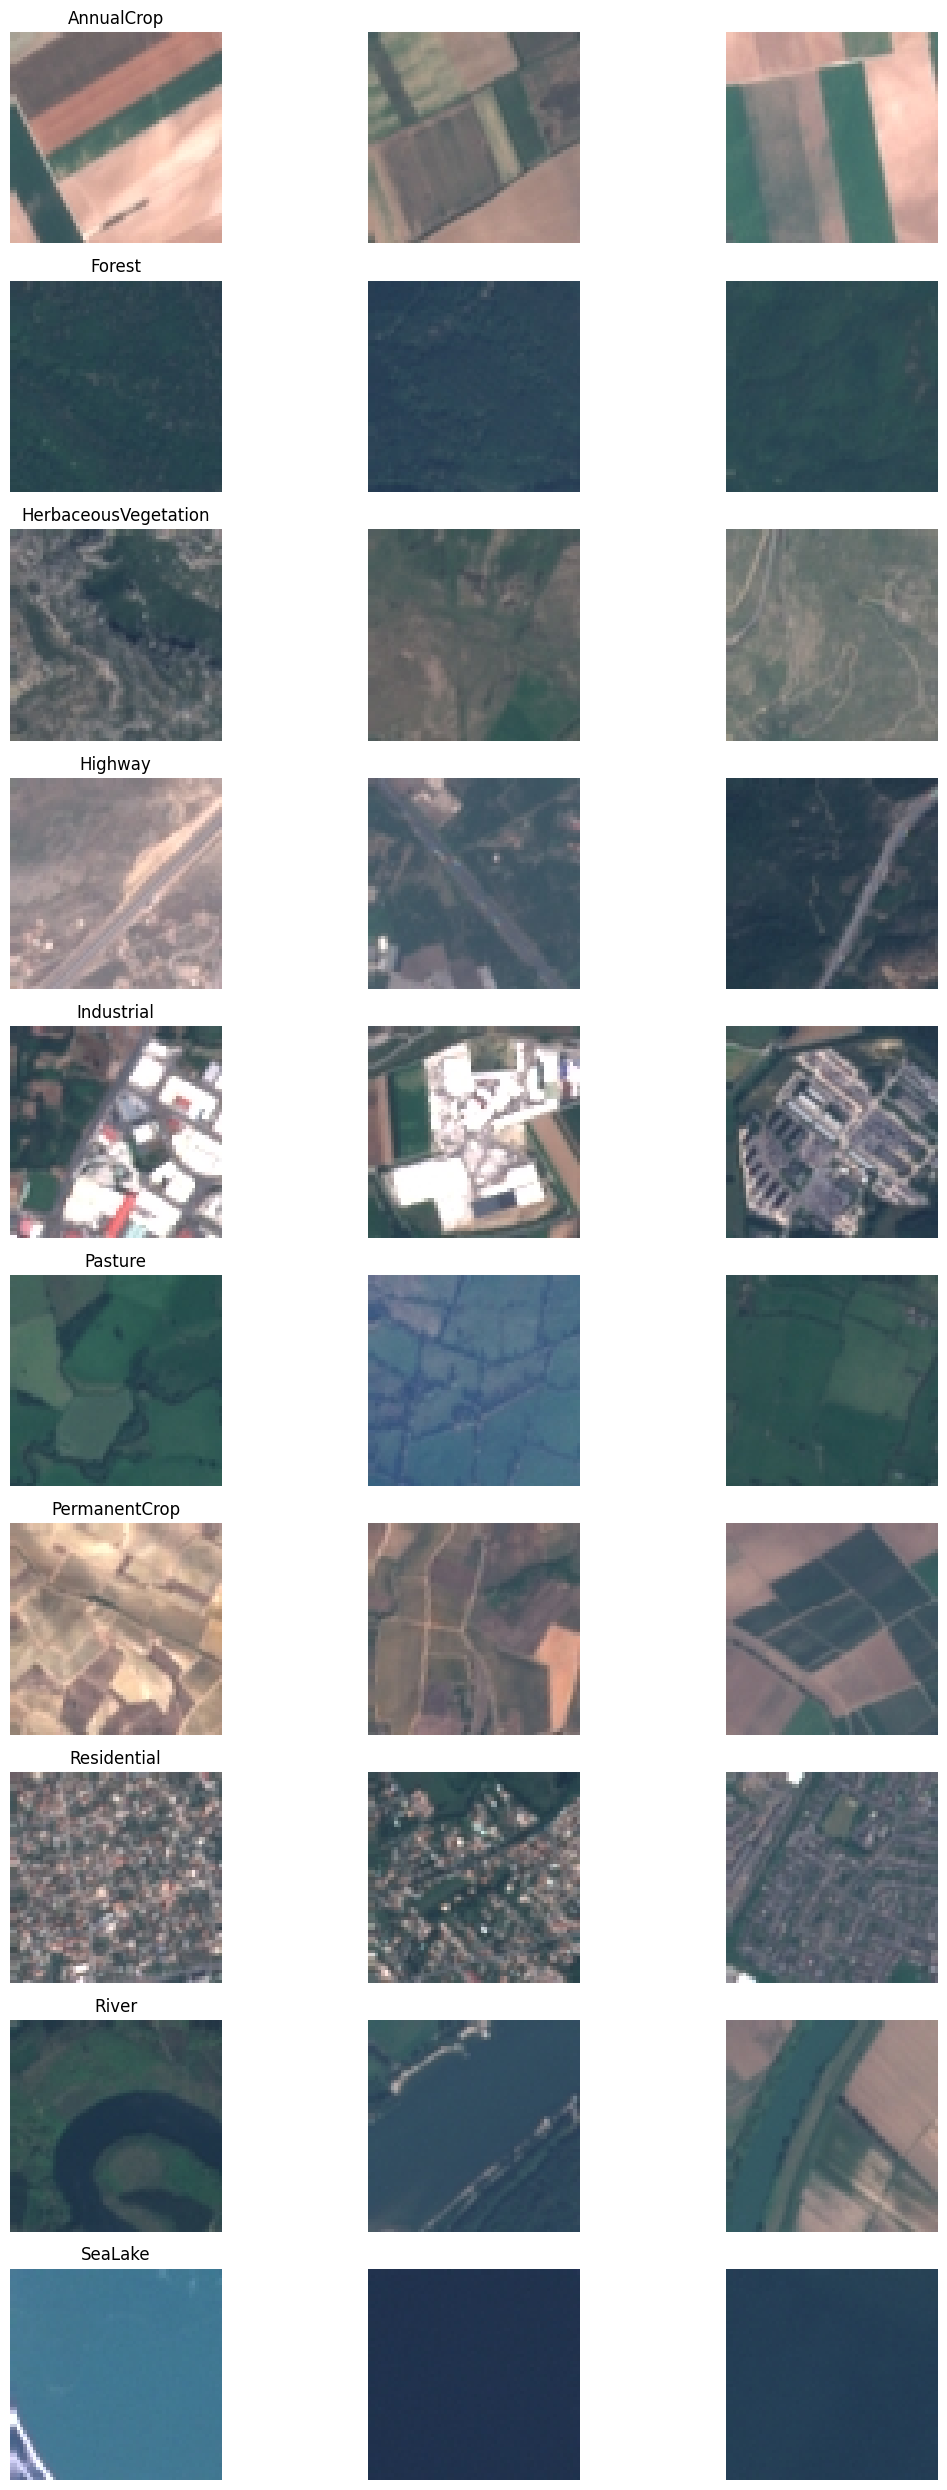

In [9]:
# Import libraries for visualization
import matplotlib.pyplot as plt
from PIL import Image
import random
from pathlib import Path

def show_samples(df, label_dict, samples_per_class=3):
    """
    Displays random image samples from each class.
    """

    # Create a grid of subplots
    fig, axes = plt.subplots(
        len(label_dict),
        samples_per_class,
        figsize=(12, 25)
    )

    # Iterate through all classes
    for label, class_name in label_dict.items():

        # Select images belonging to the current class
        class_df = df[df["label"] == label]

        # Randomly sample images from the class
        samples = class_df.sample(
            samples_per_class,
            random_state=42
        )

        # Display sampled images
        for j, (_, row) in enumerate(samples.iterrows()):

            img_path = Path(row["folder"]) / row["file_name"]
            img = Image.open(img_path)

            axes[label, j].imshow(img)
            axes[label, j].axis("off")

            # Show class name on the first image of each row
            if j == 0:
                axes[label, j].set_title(class_name)

    # Adjust spacing and display figure
    plt.tight_layout()
    plt.show()

# Visualize sample images from each class
show_samples(dataset, label_dict)

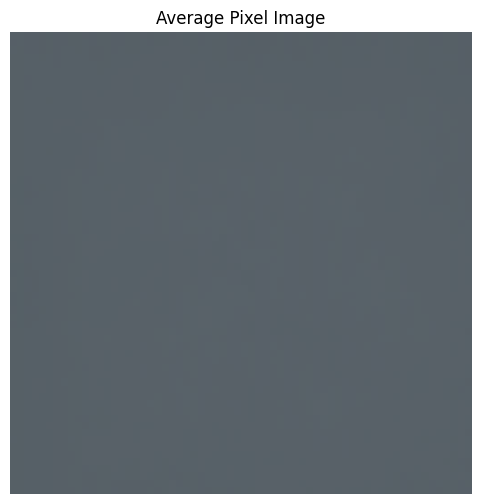

In [10]:
# Import NumPy for image processing
import numpy as np

def average_pixel_plot(df):
    """
    Computes and displays the average image of the dataset.
    """

    # Initialize an empty image for accumulating pixel values
    avg_image = np.zeros((64, 64, 3), dtype=np.float64)

    # Sum pixel values of all images
    for _, row in df.iterrows():

        img_path = Path(row["folder"]) / row["file_name"]

        img = np.array(Image.open(img_path)) / 255.0

        avg_image += img

    # Compute mean pixel values
    avg_image /= len(df)

    # Display the average image
    plt.figure(figsize=(6, 6))
    plt.imshow(avg_image)
    plt.title("Average Pixel Image")
    plt.axis("off")
    plt.show()

# Generate average image visualization
average_pixel_plot(dataset)

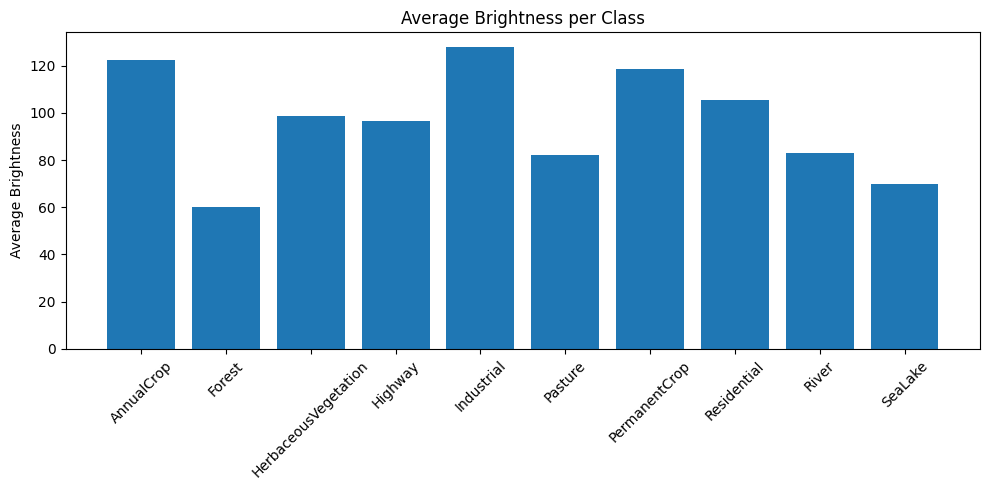

In [11]:
# Compute and visualize average image brightness for each class
def average_brightness_per_class(df, label_dict):
    """
    Calculates the average brightness of images in each class
    and displays the results as a bar chart.
    """

    brightness_values = []
    class_names = []

    # Iterate through all classes
    for label, class_name in label_dict.items():

        class_df = df[df["label"] == label]

        brightness = []

        # Compute brightness for each image in the class
        for _, row in class_df.iterrows():

            img_path = Path(row["folder"]) / row["file_name"]

            img = np.array(Image.open(img_path))

            brightness.append(img.mean())

        # Store average class brightness
        brightness_values.append(np.mean(brightness))
        class_names.append(class_name)

    # Create bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(class_names, brightness_values)

    plt.xticks(rotation=45)
    plt.ylabel("Average Brightness")
    plt.title("Average Brightness per Class")

    plt.tight_layout()
    plt.show()

# Display brightness comparison across classes
average_brightness_per_class(dataset, label_dict)

## CNN Implementation and Training

### Dataset class

In [12]:
# Import required libraries for dataset handling
import torch
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path
import torchvision.transforms as transforms

# Custom dataset class for loading satellite images
class SatelliteDataset(Dataset):
    def __init__(self, df, transform=None, has_labels=True):
        # Store dataset information and preprocessing transforms
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        # Return the total number of samples
        return len(self.df)

    def __getitem__(self, idx):
        # Retrieve image metadata
        row = self.df.iloc[idx]
        img_path = Path(row["folder"]) / row["file_name"]

        # Load image and convert to RGB format
        image = Image.open(img_path).convert("RGB")

        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)

        # Return image and label for training/validation
        if self.has_labels:
            label = int(row["label"])
            return image, label

        # Return image and filename for unlabeled test data
        return image, row["file_name"]

### Data Loaders

In [13]:
# your code goes here

from torch.utils.data import DataLoader
import torchvision.transforms as transforms

BATCH_SIZE = 64

# Data augmentation for the training images
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.3444, 0.3802, 0.4078],
        std=[0.2037, 0.1366, 0.1148]
    )
])

# Validation images are only converted and normalized
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.3444, 0.3802, 0.4078],
        std=[0.2037, 0.1366, 0.1148]
    )
])

# Create dataset objects
train_dataset = SatelliteDataset(
    train_df,
    transform=train_transform
)

val_dataset = SatelliteDataset(
    val_df,
    transform=val_transform
)

# Create data loaders for batching the data
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 125
Validation batches: 32


### Model Architecture

In [14]:
# your code goes here

import torch
import torch.nn as nn
import torch.nn.functional as F

# Simple CNN model for image classification
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Convolutional layers extract image features
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16 -> 8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8 -> 4
        )

        # Fully connected layers make the final class prediction
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Pass input through feature extractor and classifier
        x = self.features(x)
        x = self.classifier(x)
        return x


# Use GPU if available, otherwise use CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN(num_classes=10).to(DEVICE)

print(model)
print("Device:", DEVICE)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affin

### Training Loop

In [15]:
# your code goes here
import torch.optim as optim
import os

EPOCHS = 70
LR = 0.001

# Set loss function, optimizer, and learning-rate scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

best_val_acc = 0.0

# Store loss and accuracy values for later plots
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

# Folder and path for saving the best model
os.makedirs("assets/weights", exist_ok=True)
BEST_MODEL_PATH = "assets/weights/best_model.pth"


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients before each update
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation and weight update
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient calculation during validation
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


# Training loop
for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step()

    # Save metrics for later visualization
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save only the model with the best validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best model saved.")

print("Best validation accuracy:", best_val_acc)

Epoch [1/70] Train Loss: 1.2875 Train Acc: 0.5404 Val Loss: 0.9076 Val Acc: 0.6870
Best model saved.
Epoch [2/70] Train Loss: 0.8963 Train Acc: 0.6834 Val Loss: 0.7801 Val Acc: 0.7230
Best model saved.
Epoch [3/70] Train Loss: 0.7772 Train Acc: 0.7228 Val Loss: 0.7768 Val Acc: 0.7200
Epoch [4/70] Train Loss: 0.7364 Train Acc: 0.7438 Val Loss: 0.6650 Val Acc: 0.7660
Best model saved.
Epoch [5/70] Train Loss: 0.6745 Train Acc: 0.7696 Val Loss: 0.5515 Val Acc: 0.8045
Best model saved.
Epoch [6/70] Train Loss: 0.5590 Train Acc: 0.8076 Val Loss: 0.4733 Val Acc: 0.8390
Best model saved.
Epoch [7/70] Train Loss: 0.5211 Train Acc: 0.8177 Val Loss: 0.6187 Val Acc: 0.7865
Epoch [8/70] Train Loss: 0.4847 Train Acc: 0.8379 Val Loss: 0.4047 Val Acc: 0.8585
Best model saved.
Epoch [9/70] Train Loss: 0.4634 Train Acc: 0.8409 Val Loss: 0.4315 Val Acc: 0.8495
Epoch [10/70] Train Loss: 0.4595 Train Acc: 0.8433 Val Loss: 0.4275 Val Acc: 0.8495
Epoch [11/70] Train Loss: 0.3891 Train Acc: 0.8670 Val Loss: 

In [24]:
# Number of additional training epochs
EPOCHS_EXTRA = 10

# Lower the learning rate for fine-tuning
for param_group in optimizer.param_groups:
    param_group["lr"] = 0.0003

# Continue training the model
for epoch in range(EPOCHS_EXTRA):

    # Train model for one epoch
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    # Evaluate model on validation data
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, DEVICE
    )

    # Store training and validation metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Print current epoch results
    print(
        f"Extra Epoch [{epoch+1}/{EPOCHS_EXTRA}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save model if validation accuracy improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best model saved.")

# Print best validation accuracy after extra training
print("Best validation accuracy:", best_val_acc)

Extra Epoch [1/10] Train Loss: 0.3047 Train Acc: 0.8956 Val Loss: 0.3929 Val Acc: 0.8645
Extra Epoch [2/10] Train Loss: 0.2946 Train Acc: 0.8985 Val Loss: 0.3040 Val Acc: 0.9055
Extra Epoch [3/10] Train Loss: 0.2929 Train Acc: 0.9034 Val Loss: 0.3731 Val Acc: 0.8745
Extra Epoch [4/10] Train Loss: 0.2729 Train Acc: 0.9051 Val Loss: 0.3621 Val Acc: 0.8675
Extra Epoch [5/10] Train Loss: 0.2842 Train Acc: 0.9042 Val Loss: 0.3061 Val Acc: 0.8995
Extra Epoch [6/10] Train Loss: 0.2763 Train Acc: 0.9062 Val Loss: 0.2960 Val Acc: 0.9040
Extra Epoch [7/10] Train Loss: 0.2782 Train Acc: 0.9061 Val Loss: 0.2483 Val Acc: 0.9205
Extra Epoch [8/10] Train Loss: 0.2554 Train Acc: 0.9117 Val Loss: 0.2611 Val Acc: 0.9175
Extra Epoch [9/10] Train Loss: 0.2624 Train Acc: 0.9103 Val Loss: 0.2720 Val Acc: 0.9095
Extra Epoch [10/10] Train Loss: 0.2726 Train Acc: 0.9034 Val Loss: 0.2760 Val Acc: 0.9020
Best validation accuracy: 0.9255


## Model Evaluation

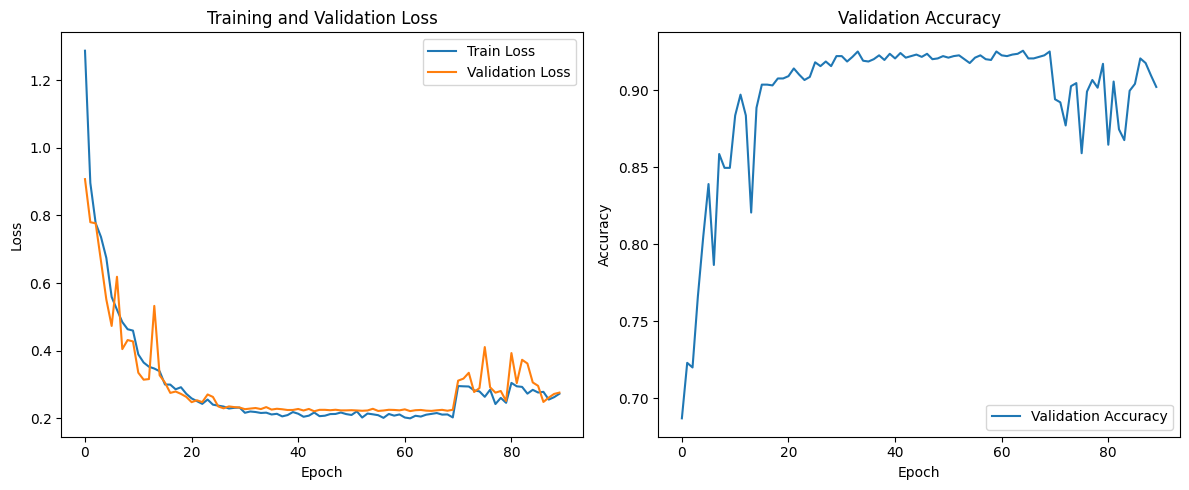

In [25]:
# Load the best-performing model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

# Create plots for training history
plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

# Adjust layout and display plots
plt.tight_layout()
plt.show()

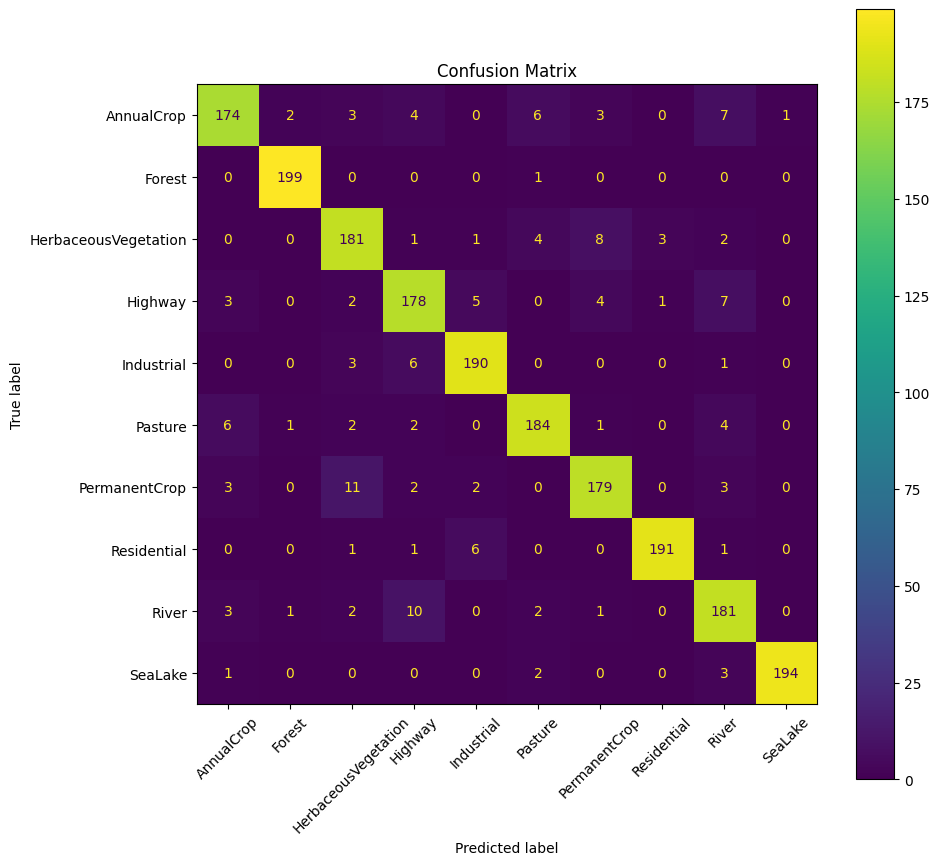

In [26]:
# Import tools for confusion matrix visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

# Switch model to evaluation mode
model.eval()

# Generate predictions on the validation set
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Create confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[label_dict[i] for i in range(10)]
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

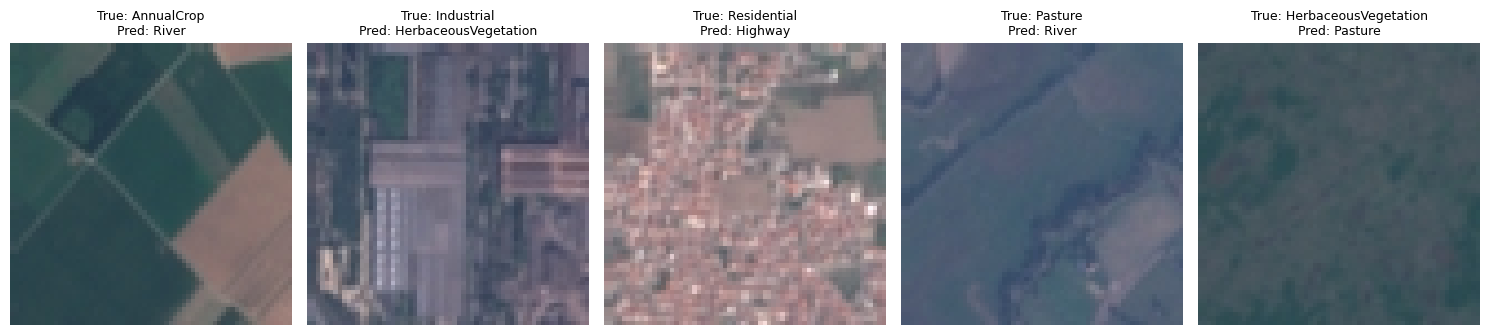

In [28]:
# Display incorrectly classified validation samples
def show_misclassified_samples(model, loader, label_dict, device, num_samples=5):
    model.eval()

    misclassified = []

    # Collect misclassified images
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu()

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append(
                        (images[i].cpu(), labels[i].item(), preds[i].item())
                    )

                if len(misclassified) >= num_samples:
                    break

            if len(misclassified) >= num_samples:
                break

    # Create visualization
    plt.figure(figsize=(15, 4))

    for i, (img, true_label, pred_label) in enumerate(misclassified):
        img = img.permute(1, 2, 0).numpy()

        # Reverse image normalization for display
        mean = np.array([0.3444, 0.3802, 0.4078])
        std = np.array([0.2037, 0.1366, 0.1148])
        img = img * std + mean
        img = np.clip(img, 0, 1)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.axis("off")

        # Display true and predicted labels
        plt.title(
            f"True: {label_dict[true_label]}\nPred: {label_dict[pred_label]}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

# Visualize a few misclassified samples
show_misclassified_samples(model, val_loader, label_dict, DEVICE)

### Test Set

In [29]:
# Create a dataframe containing all test images
def preprocess_test(data_folder):
    data_folder = Path(data_folder)

    rows = []

    # Collect filenames of all test images
    for img_path in sorted(data_folder.glob("*.jpg")):
        rows.append({
            "folder": str(data_folder),
            "file_name": img_path.name
        })

    # Convert image information into a dataframe
    return pd.DataFrame(rows)

# Load test dataset metadata
test_df = preprocess_test(TEST_DIR)

# Display dataset information
print(test_df.head())
print("Number of test images:", len(test_df))

             folder file_name
0  public_test_data  1001.jpg
1  public_test_data  1002.jpg
2  public_test_data  1008.jpg
3  public_test_data   101.jpg
4  public_test_data  1034.jpg
Number of test images: 1980


In [30]:
# Create dataset for test images
test_dataset = SatelliteDataset(
    test_df,
    transform=val_transform,
    has_labels=False
)

# Create DataLoader for batch-wise inference
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

# Display number of test batches
print("Test batches:", len(test_loader))

Test batches: 31


In [31]:
# Load the best-performing model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

test_predictions = []

# Generate predictions for the test dataset
with torch.no_grad():
    for images, file_names in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        # Store filename and predicted class
        for file_name, pred in zip(file_names, preds):
            class_name = label_dict[int(pred)]
            test_predictions.append([file_name, class_name])

# Display a few predictions
print(test_predictions[:10])

[['1001.jpg', 'HerbaceousVegetation'], ['1002.jpg', 'Residential'], ['1008.jpg', 'HerbaceousVegetation'], ['101.jpg', 'Highway'], ['1034.jpg', 'HerbaceousVegetation'], ['1042.jpg', 'AnnualCrop'], ['1046.jpg', 'PermanentCrop'], ['1049.jpg', 'AnnualCrop'], ['1056.jpg', 'PermanentCrop'], ['1066.jpg', 'Pasture']]


In [32]:
# Create submission dataframe from test predictions
submission_df = pd.DataFrame(test_predictions)

# Save predictions in the required CSV format
submission_df.to_csv(
    "submission.csv",
    index=False,
    header=False
)

# Display submission information
print("Submission file created.")
print("Rows:", len(submission_df))
print(submission_df.head(10))

Submission file created.
Rows: 1980
          0                     1
0  1001.jpg  HerbaceousVegetation
1  1002.jpg           Residential
2  1008.jpg  HerbaceousVegetation
3   101.jpg               Highway
4  1034.jpg  HerbaceousVegetation
5  1042.jpg            AnnualCrop
6  1046.jpg         PermanentCrop
7  1049.jpg            AnnualCrop
8  1056.jpg         PermanentCrop
9  1066.jpg               Pasture


In [2]:
#AI was used only for occasional guidance when I was unsure how to continue. All submitted code was written, checked, and understood by me.
